In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [10]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Entropy
<pre>Decision Tree Learning
Hunt’s Algorithm</pre>
## (Parent)
<pre>P=positive entries/total entries
N=negative entries/total entries</pre>
<pre>-P(log P)-N(log N)
(log base 2)</pre>

## Weighted Entropy
Summation((Total child values/Total values)*child entropy)

## Info Gain(IG)
Parent Entropy - Weighted Entropy

0.7207792207792207
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



[Text(0.47609544836956524, 0.9705882352941176, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.17909307065217392, 0.9117647058823529, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.32759425951086957, 0.9411764705882353, 'True  '),
 Text(0.06521739130434782, 0.8529411764705882, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.021739130434782608, 0.7941176470588235, 'DiabetesPedigreeFunction <= 0.672\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.010869565217391304, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.03260869565217391, 0.7352941176470589, 'DiabetesPedigreeFunction <= 0.686\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.021739130434782608, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.043478260869565216, 0.6764705882352942, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.10869565217391304, 0.7941

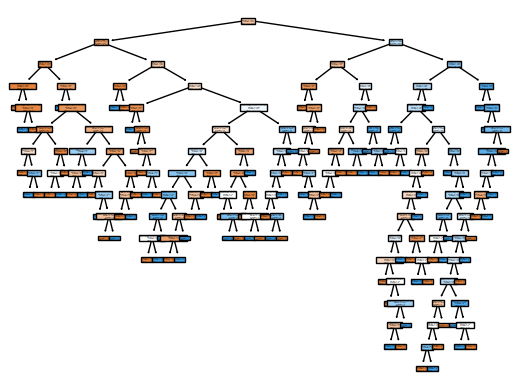

In [15]:
x=df.drop('Outcome',axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
plot_tree(dt,feature_names=x.columns,filled=True)

0.7662337662337663
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



[Text(0.5, 0.875, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.25, 0.625, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.0625, 0.125, 'entropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.1875, 0.125, 'entropy = 0.646\nsamples = 97\nvalue = [81, 16]'),
 Text(0.375, 0.375, 'BMI <= 26.35\nentropy = 0.933\nsamples = 169\nvalue = [110, 59]'),
 Text(0.3125, 0.125, 'entropy = 0.191\nsamples = 34\nvalue = [33, 1]'),
 Text(0.4375, 0.125, 'entropy = 0.986\nsamples = 135\nvalue = [77, 58]'),
 Text(0.75, 0.625, 'BMI <= 29.95\nentropy = 0.964\nsamples = 224\nvalue = [87, 137]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Glucose <= 145.5\nentropy = 0.895\nsamples = 61\nvalue = [42, 19]'),
 Text(0.5625, 0.125, 'entropy = 0.533\nsamples = 33\nvalue = [29, 4]'),
 Text(0.6875, 0.125, 'entropy = 0.996\nsampl

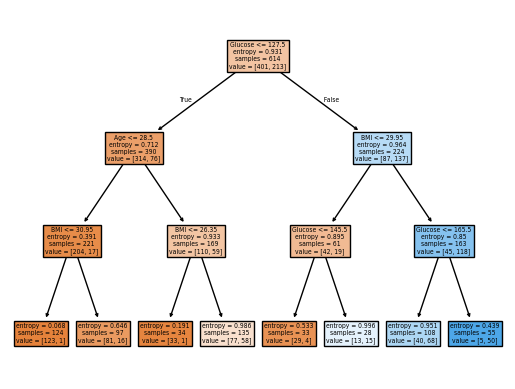

In [24]:
x=df.drop('Outcome',axis=1)
y=df["Outcome"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=3)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
plot_tree(dt,feature_names=x.columns,filled=True)

[Text(0.47609544836956524, 0.9705882352941176, '0.7727272727272727 <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.17909307065217392, 0.9117647058823529, '0.7662337662337663 <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.32759425951086957, 0.9411764705882353, 'True  '),
 Text(0.06521739130434782, 0.8529411764705882, '0.7402597402597403 <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.021739130434782608, 0.7941176470588235, '0.7402597402597403 <= 0.672\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.010869565217391304, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.03260869565217391, 0.7352941176470589, '0.7402597402597403 <= 0.686\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.021739130434782608, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.043478260869565216, 0.6764705882352942, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Tex

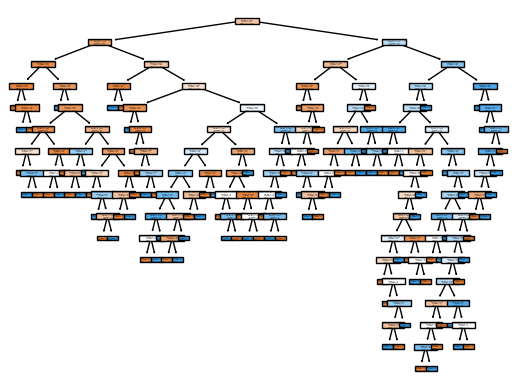

In [22]:
x=df.drop('Outcome',axis=1)
y=df["Outcome"]
ac=[]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
for i in range(1,51):
    dt=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=i)
    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    ac.append(accuracy_score(y_test,y_pred))
    # print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))
plot_tree(dt,feature_names=ac,filled=True)

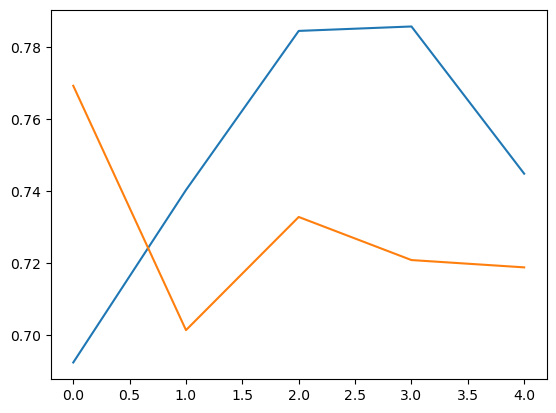

In [36]:
from sklearn.neighbors import KNeighborsClassifier
x=df.drop('Outcome',axis=1)
y=df["Outcome"]
ac=[]
ac_knn=[]
ts=[0.05,0.1,0.15,0.2,0.25]
for i in ts:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    dt=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=5)
    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    ac.append(accuracy_score(y_test,y_pred))
    knn=KNeighborsClassifier(n_neighbors=31)
    knn.fit(x_train,y_train)
    y_pred1=knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test,y_pred1))
    # print(accuracy_score(y_test,y_pred))
    # print(classification_report(y_test,y_pred))
plt.plot(ac)
plt.plot(ac_knn)